# Histogram Equalization

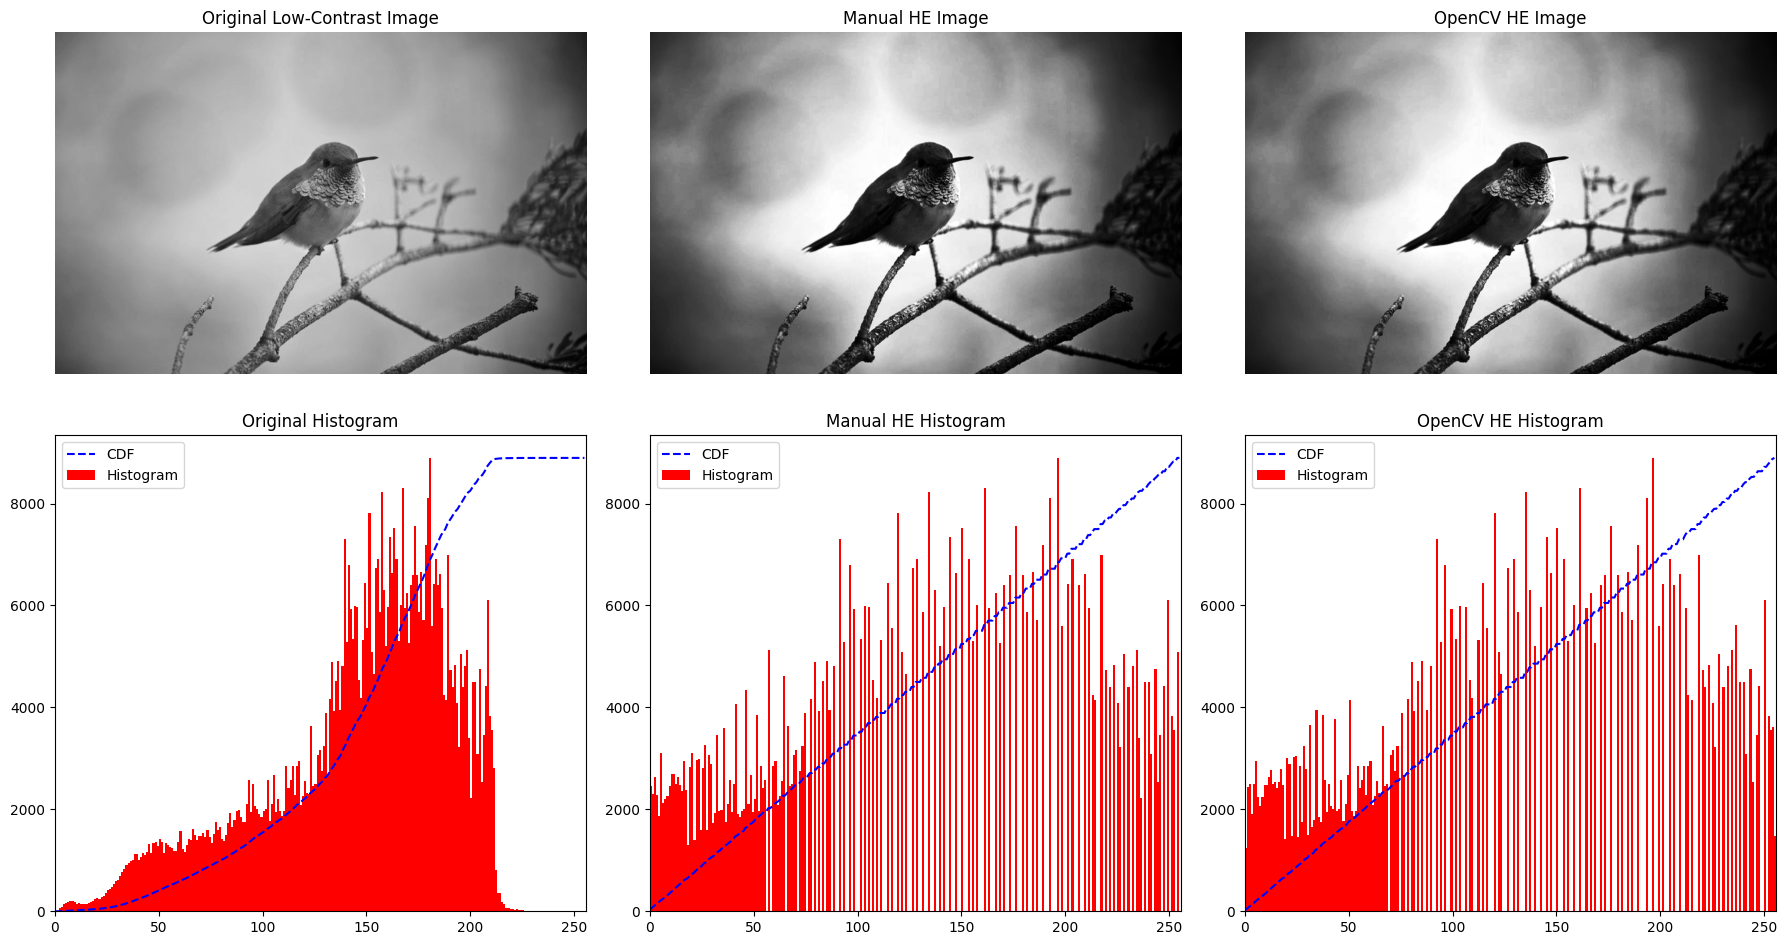

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def plot_histogram(img, title, ax):
    """Helper function to plot histogram and CDF."""
    hist, bins = np.histogram(img.flatten(), 256, [0, 256])
    
    # Calculate CDF
    cdf = hist.cumsum()
    cdf_normalized = cdf * hist.max() / cdf.max() # Normalize for plotting
    
    ax.set_title(title)
    ax.plot(cdf_normalized, color='b', linestyle='--')
    ax.hist(img.flatten(), 256, [0, 256], color='r')
    ax.legend(('CDF', 'Histogram'), loc='upper left')
    ax.set_xlim([0, 256])

# Load inage
img = cv2.imread('C:/Meet/PDEU/Semester 7/Computer Vision Lab/Computer-Vision/Images/Grayscale_Image.jpg', cv2.IMREAD_GRAYSCALE)

# --- 1. Manual Histogram Equalization ---

# Calculate histogram
hist, bins = np.histogram(img.flatten(), 256, [0, 256])

# Calculate CDF
cdf = hist.cumsum()

# Create the lookup table (LUT)
# We mask 0s to avoid division by zero if an image has no pixels of a certain value
cdf_m = np.ma.masked_equal(cdf, 0)
cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())

# Fill back masked values with 0
cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')

# Apply the LUT to the original image
img_manual_he = cdf_final[img]


# --- 2. OpenCV's Built-in HE ---
img_cv2_he = cv2.equalizeHist(img)


# --- 3. Analysis and Visualization ---
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# Original Image
axs[0, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
axs[0, 0].set_title('Original Low-Contrast Image')
axs[0, 0].axis('off')
plot_histogram(img, 'Original Histogram', axs[1, 0])

# Manual HE Image
axs[0, 1].imshow(img_manual_he, cmap='gray', vmin=0, vmax=255)
axs[0, 1].set_title('Manual HE Image')
axs[0, 1].axis('off')
plot_histogram(img_manual_he, 'Manual HE Histogram', axs[1, 1])

# OpenCV HE Image
axs[0, 2].imshow(img_cv2_he, cmap='gray', vmin=0, vmax=255)
axs[0, 2].set_title('OpenCV HE Image')
axs[0, 2].axis('off')
plot_histogram(img_cv2_he, 'OpenCV HE Histogram', axs[1, 2])

plt.tight_layout()
plt.show()